# **Sentiment Analysis of Recipe Reviews Using Classical NLP Techniques**

## **1. Project Objective**


This project applies Natural Language Processing (NLP) and machine learning techniques to recipe reviews. The analysis includes sentiment exploration, text preprocessing, feature extraction, classification modeling, and evaluation of methods for handling imbalanced data.







     

## **2. Import General Libraries**

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## **3. Load Dataset**

In [68]:
df = pd.read_csv('/content/sample_data/Recipe Reviews and User Feedback Dataset.csv')

print(df.shape)

df.head()

(18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


## **4. Dataset Overview**

In [69]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       18182 non-null  int64 
 1   recipe_number    18182 non-null  int64 
 2   recipe_code      18182 non-null  int64 
 3   recipe_name      18182 non-null  object
 4   comment_id       18182 non-null  object
 5   user_id          18182 non-null  object
 6   user_name        18182 non-null  object
 7   user_reputation  18182 non-null  int64 
 8   created_at       18182 non-null  int64 
 9   reply_count      18182 non-null  int64 
 10  thumbs_up        18182 non-null  int64 
 11  thumbs_down      18182 non-null  int64 
 12  stars            18182 non-null  int64 
 13  best_score       18182 non-null  int64 
 14  text             18180 non-null  object
dtypes: int64(10), object(5)
memory usage: 2.1+ MB


In [70]:
# Check Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
recipe_number,0
recipe_code,0
recipe_name,0
comment_id,0
user_id,0
user_name,0
user_reputation,0
created_at,0
reply_count,0


#### **Observation**
Only the text column contains missing values.

In [71]:
# Handle Missing Values
df['text'].fillna('', inplace=True)

In [72]:
# Remove Unnecessary Columns
df.drop(columns='Unnamed: 0', inplace=True)

In [73]:
# Check Duplicates
print(df.duplicated().sum())

0


#### **Observation**
No duplicated rows were found.

## **5. Data Cleaning & Feature Engineering**

In [74]:
# Rename Columns
df.rename(columns={
    'text': 'review',
    'best_score': 'rev_best_score',
    'recipe_number': 'recipe_rank',
    'reply_count': 'rev_reply_count'
}, inplace=True)

In [75]:
# Convert Timestamp
df['created_at'] = pd.to_datetime(df['created_at'], unit='s')

In [76]:
# Extract Time Features
df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month
df['day'] = df['created_at'].dt.day
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_name()

In [77]:
# Review Length Feature
# source: https://www.kaggle.com/code/joebeachcapital/recipe-reviews-data-import-eda-starter/notebook
df['review_length'] = df['review'].apply(lambda x: len(str(x)))

Review length may reflect:



*   User engagement
*   Emotional intensity



*   Review detail level
*   Sentiment strength





## **6. Descriptive Statistics**

In [78]:
# Numerical Features
df.describe()

,recipe_rank,recipe_code,user_reputation,created_at,rev_reply_count,thumbs_up,thumbs_down,stars,rev_best_score,year,month,day,hour,review_length
count,18182.000000,18182.000000,18182.000000,18182,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000
mean,38.689363,21773.667253,2.159608,2021-06-14 22:41:25.783631872,0.014630,1.089264,0.549335,4.288802,153.162138,2021.028710,6.009020,3.697393,10.632604,203.887251
min,1.000000,386.000000,0.000000,2021-02-11 09:22:16,0.000000,0.000000,0.000000,0.000000,0.000000,2021.000000,1.000000,1.000000,0.000000,0.000000
25%,12.000000,6086.000000,1.000000,2021-06-03 10:47:19,0.000000,0.000000,0.000000,5.000000,100.000000,2021.000000,6.000000,3.000000,10.000000,90.000000
50%,33.000000,14600.000000,1.000000,2021-06-03 10:55:07,0.000000,0.000000,0.000000,5.000000,100.000000,2021.000000,6.000000,3.000000,10.000000,161.000000
75%,64.000000,33121.000000,1.000000,2021-06-03 11:02:51,0.000000,0.000000,0.000000,5.000000,100.000000,2021.000000,6.000000,3.000000,11.000000,266.000000
max,100.000000,191775.000000,520.000000,2022-10-14 14:00:35,3.000000,106.000000,126.000000,5.000000,946.000000,2022.000000,12.000000,31.000000,23.000000,2742.000000
std,29.786647,23965.109637,10.014666,NaN,0.137974,4.201004,3.470124,1.544786,141.075316,0.166994,0.815346,3.556973,2.069708,172.459399


In [79]:
# Categorical Features
df.describe(include=['object'])

,recipe_name,comment_id,user_id,user_name,review,day_of_week
count,18182,18182,18182,18182,18182,18182
unique,100,18182,13812,13586,17732,7
top,Cheeseburger Soup,sp_aUSaElGf_82745_c_262637,u_1oKVZzipo1u8lcqQzDUcw4UBn9e,2124arizona,Delicious!,Thursday
freq,725,1,25,28,14,16915


## **7. Exploratory Data Analysis (EDA)**

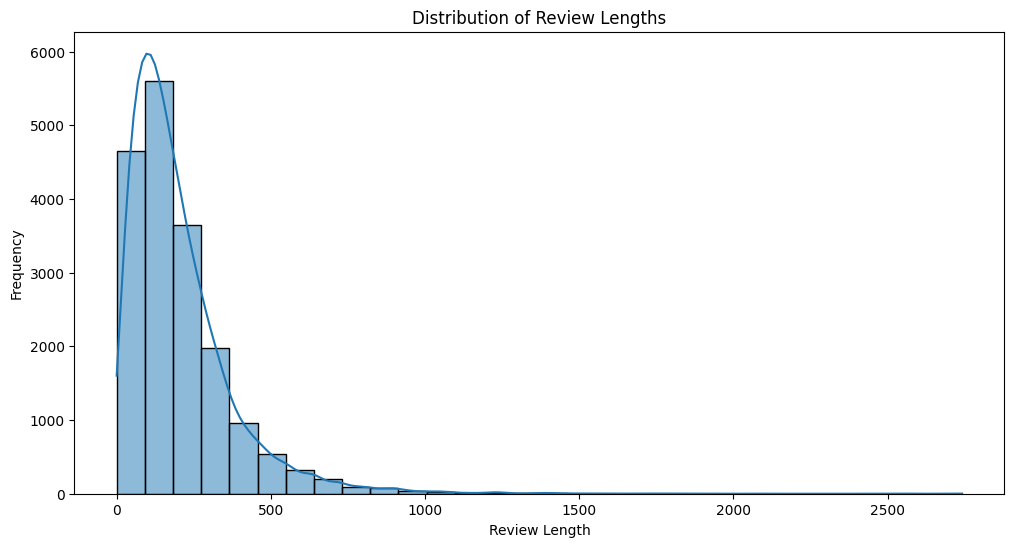

In [80]:
# Review Length Distribution
# source: https://www.kaggle.com/code/joebeachcapital/recipe-reviews-data-import-eda-starter/notebook
plt.figure(figsize=(12,6))

sns.histplot(df['review_length'], bins=30, kde=True)

plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.show()

#### **Observation**
Most reviews are relatively short, while a smaller number of reviews are significantly longer.

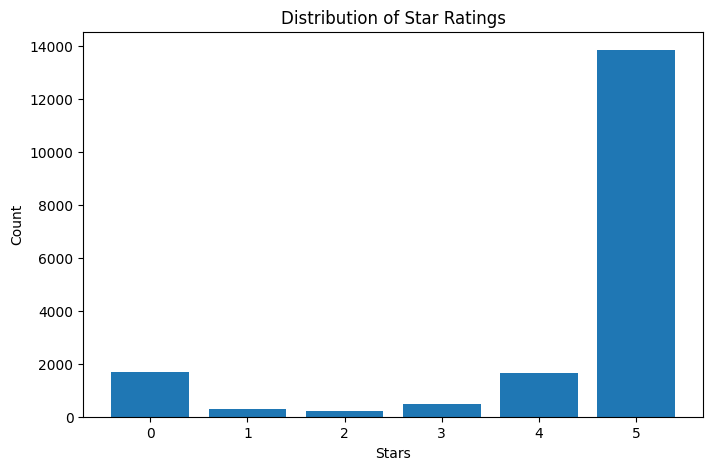

In [81]:
# Star Rating Distribution
plt.figure(figsize=(8,5))

plt.bar(
    df['stars'].value_counts().index,
    df['stars'].value_counts().values
)

plt.title('Distribution of Star Ratings')
plt.xlabel('Stars')
plt.ylabel('Count')

plt.show()

#### **Observation**


*   The dataset is highly imbalanced toward positive reviews, especially 5-star ratings.
*   This imbalance may negatively affect classification performance on minority classes.






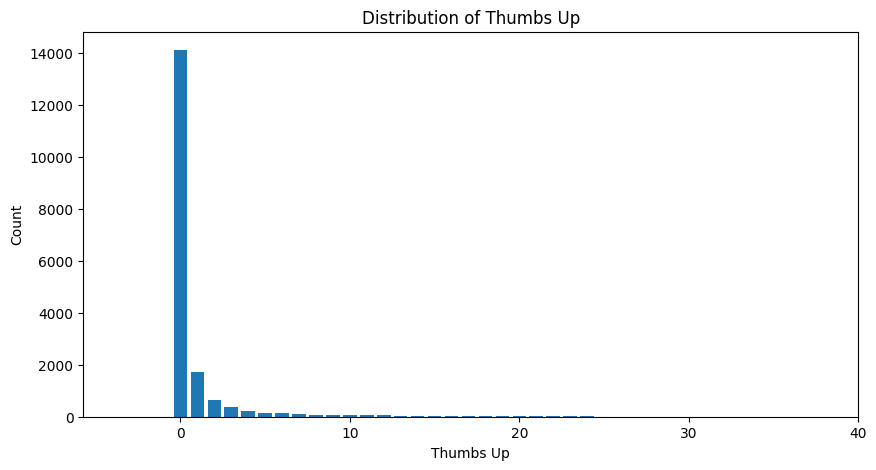

In [82]:
# Thumbs Up Distribution
plt.figure(figsize=(10,5))

plt.bar(
    df['thumbs_up'].value_counts().index,
    df['thumbs_up'].value_counts().values
)

plt.xlim(right=40)

plt.title('Distribution of Thumbs Up')
plt.xlabel('Thumbs Up')
plt.ylabel('Count')

plt.show()

#### **Observation**
Most reviews receive zero engagement, indicating sparse user interaction.

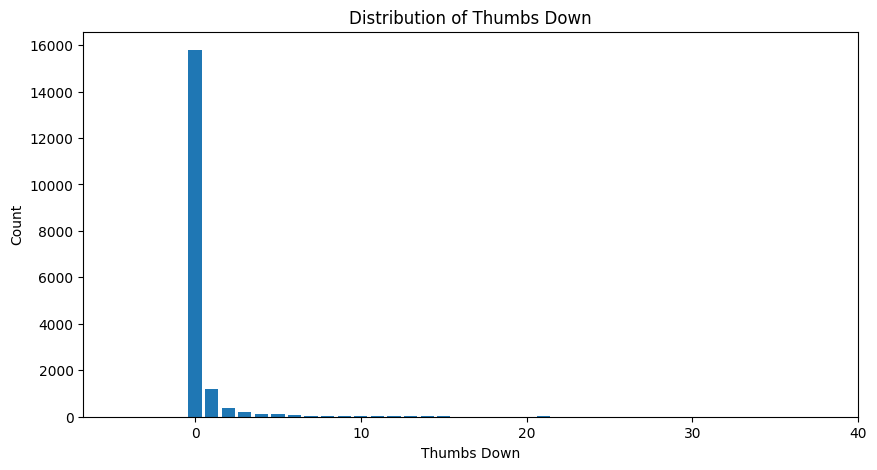

In [83]:
# Thumbs Down Distribution
plt.figure(figsize=(10,5))

plt.bar(
    df['thumbs_down'].value_counts().index,
    df['thumbs_down'].value_counts().values
)

plt.xlim(right=40)

plt.title('Distribution of Thumbs Down')
plt.xlabel('Thumbs Down')
plt.ylabel('Count')

plt.show()

#### **Observation**
Negative engagement is also highly sparse and concentrated around zero.

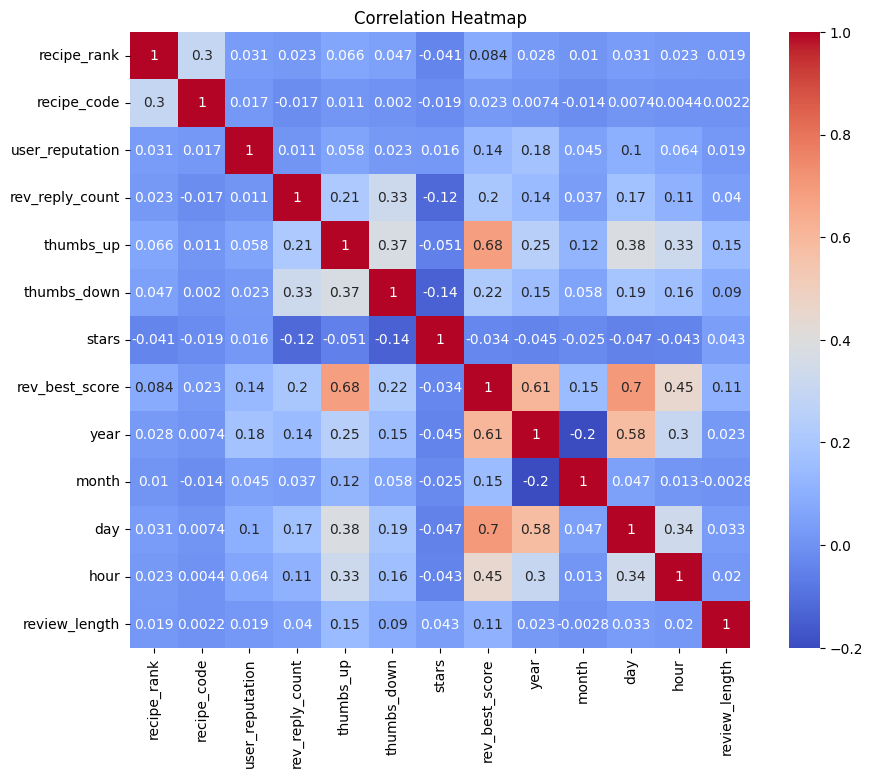

In [84]:
# Correlation Analysis
numeric_df = df.select_dtypes(include=['number'])

correlation = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

#### **Observation**
The heatmap highlights relationships between:

User engagement Review behavior Sentiment-related features

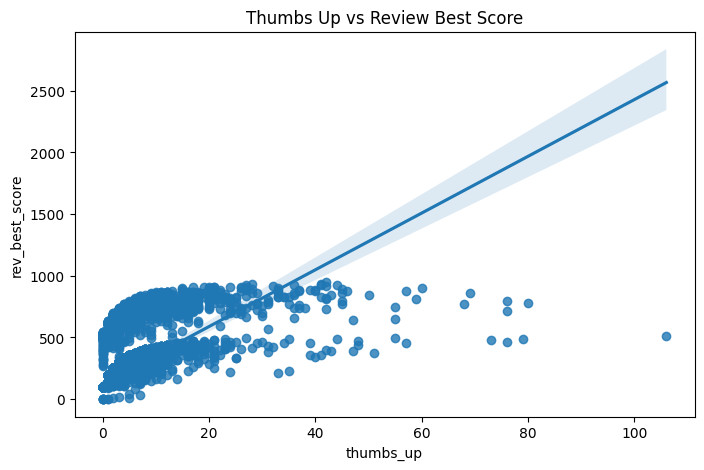

In [85]:
# Thumbs Up vs Review Score
plt.figure(figsize=(8,5))

sns.regplot(
    x='thumbs_up',
    y='rev_best_score',
    data=df
)

plt.title('Thumbs Up vs Review Best Score')

plt.show()

#### **Observation**
Reviews with higher engagement tend to receive higher review scores.

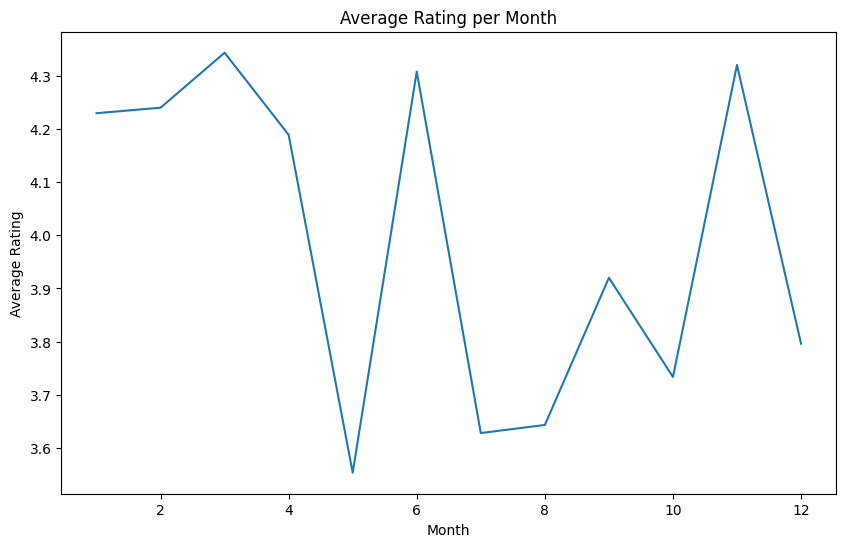

In [86]:
# Average Rating Over Time
rate_avg_month = df.groupby('month')['stars'].mean()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=rate_avg_month.index,
    y=rate_avg_month.values
)

plt.title('Average Rating per Month')
plt.xlabel('Month')
plt.ylabel('Average Rating')

plt.show()

#### **Observation**
Average ratings remain relatively stable over time with small fluctuations

## **8. Recipe-Level Analysis**

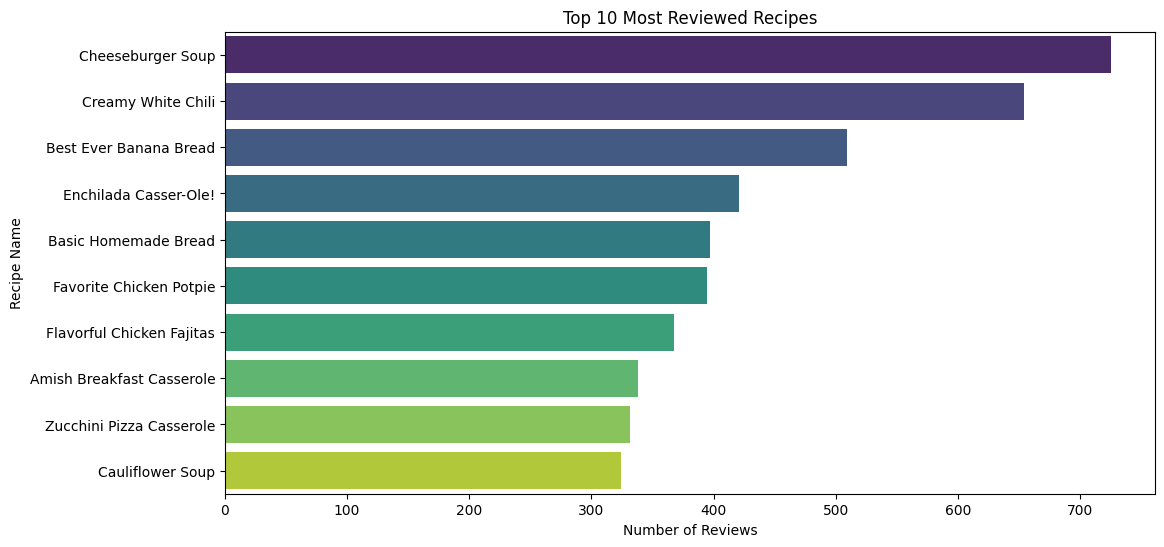

In [87]:
# Most Reviewed Recipes
recipe_frequency = df['recipe_name'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=recipe_frequency.values,
    y=recipe_frequency.index,
    palette='viridis'
)

plt.title('Top 10 Most Reviewed Recipes')
plt.xlabel('Number of Reviews')
plt.ylabel('Recipe Name')

plt.show()

In [88]:
# Highest Rated Recipes
recipe_rate = df.groupby('recipe_name')['stars'].mean().sort_values(ascending=False)

recipe_rate.head(10)

,stars
recipe_name,
Rustic Italian Tortellini Soup,4.731343
Corn Pudding,4.711409
Pumpkin Bread,4.645349
Macaroni Coleslaw,4.633508
Zucchini Pizza Casserole,4.632530
Special Banana Nut Bread,4.609023
Flavorful Chicken Fajitas,4.608696
Traditional Lasagna,4.605072
Comforting Chicken Noodle Soup,4.600000


#### **Observation**
Some recipes consistently receive high ratings, suggesting strong user satisfaction.

In [89]:
# User Reputation Analysis
user_rate = df.groupby('user_name')['user_reputation'].mean().sort_values(ascending=False)

user_rate.head()

,user_reputation
user_name,
squeakymouse,510.0
Eye,290.0
rena55,110.0
cbrooks47@comcast.net,100.0
Foxycook,95.0


## **9. NLP Preprocessing**

In [90]:
# Machine Learning Libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [91]:
# Import NLP Libraries: NLTK imports, stopwords, and WordNetLemmatizer
import nltk
# Ensure the NLTK data path is correctly set. This can sometimes help resolve lookup issues.
# Although NLTK usually searches here by default, explicit addition can be beneficial.
if '/root/nltk_data' not in nltk.data.path:
    nltk.data.path.append('/root/nltk_data')
# Download NLTK equired Resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [92]:
# Initialize NLP Tools
stop_words = stopwords.words('english')
WNlemmatizer = nltk.WordNetLemmatizer()

In [93]:
# Text Preprocessing Function
def preprocess(text):
    tokens = nltk.word_tokenize(text) # Tokenization
    tokens = [ w.lower() for w in tokens ] # Lowercasing
    tokens = [ w for w in tokens if w.isalpha() ] # Remove punctuation
    tokens = [ w for w in tokens if w not in stop_words ] # Remove stopwords
    tokens = [ WNlemmatizer.lemmatize(w, pos='v') for w in tokens ] # Lemmatization
    return tokens

## **10. Sentiment Analysis Using VADER**

In [94]:
# Import VADER
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [95]:
# Initialize Analyzer
sid = SentimentIntensityAnalyzer()

In [96]:
# Create Sentiment Scores
df['sentiment_score'] = df['review'].apply(lambda x: sid.polarity_scores(x)['compound'])

In [97]:

# Create Sentiment Labels: Positive, Neutral and Negative
def sentiment_label(score):

    if score >= 0.05:
        return 'positive'

    elif score <= -0.05:
        return 'negative'

    else:
        return 'neutral'


df['sentiment_label'] = df['sentiment_score'].apply(sentiment_label)

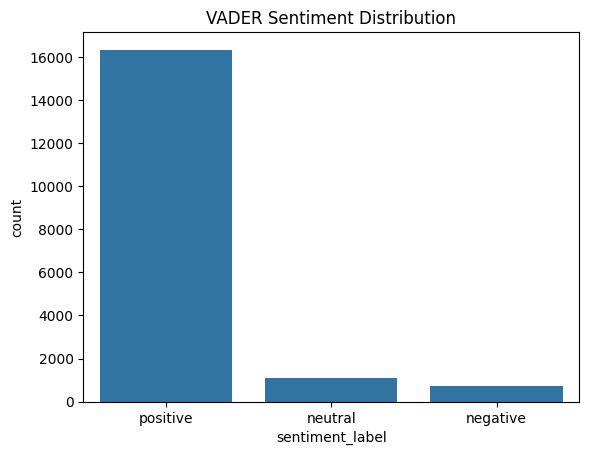

In [98]:
# Sentiment Distribution Visualization
sns.countplot(x='sentiment_label',data=df)
plt.title('VADER Sentiment Distribution')
plt.show()

#### **Observation:**

Most reviews are classified as positive, which aligns with the dominance of high star ratings observed during EDA.

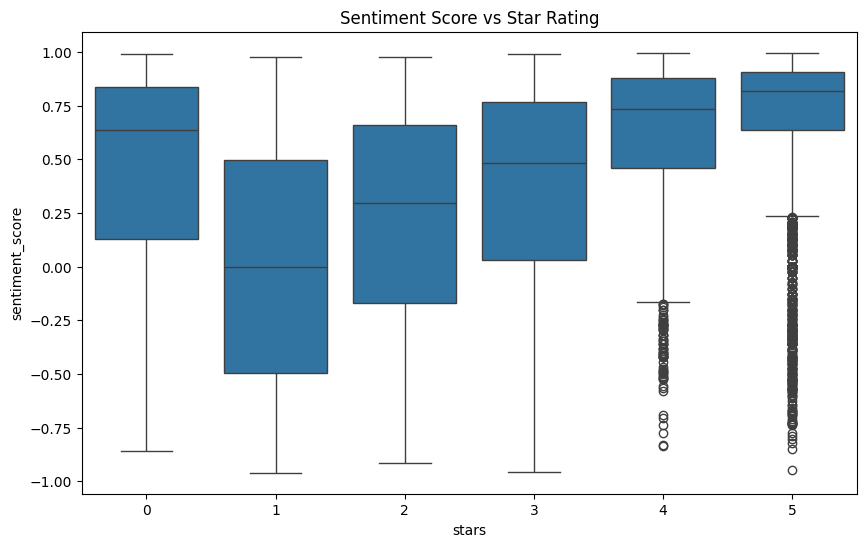

In [99]:
# Compare Sentiment Scores with Star Ratings
plt.figure(figsize=(10,6))
sns.boxplot(x='stars',y='sentiment_score',data=df)
plt.title('Sentiment Score vs Star Rating')
plt.show()

#### **Observation:**

Higher star ratings generally correspond to higher sentiment scores, suggesting consistency between user ratings and textual sentiment.

## **11. Text Vectorization**

Machine-learning models require numerical representations of text. Two common vectorization techniques were evaluated.

In [100]:
# Train-Test Split
X = df['review']

y = df['stars']

docs_train, docs_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [101]:
# Count Vectorization
count_vectorizer = CountVectorizer(
    tokenizer=preprocess,
    min_df=2,
    max_features=2000
)

X_train_count = count_vectorizer.fit_transform(docs_train)

X_test_count = count_vectorizer.transform(docs_test)

In [102]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=preprocess,
    min_df=2,
    max_features=2000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(docs_train)

X_test_tfidf = tfidf_vectorizer.transform(docs_test)

##  **12. Sentiment Classification**

### **Logistic Regression**

In [103]:
# CountVectorizer + Logistic Regression
clf_vic = LogisticRegression(max_iter=1000)
clf_vic.fit(X_train_count, y_train)
y_pred = clf_vic.predict(X_test_count)


### **Model Evaluation**

In [104]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.762


In [105]:
# Weighted F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.727


In [106]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.15      0.20       340
           1       0.30      0.17      0.22        46
           2       0.11      0.07      0.08        44
           3       0.35      0.20      0.26        98
           4       0.34      0.21      0.26       321
           5       0.83      0.94      0.88      2788

    accuracy                           0.76      3637
   macro avg       0.37      0.29      0.32      3637
weighted avg       0.71      0.76      0.73      3637



#### **Observation**
The model performs well on the dominant 5-star class but struggles with minority ratings.

In [107]:
# TF-IDF + Logistic Regression
clf_tfidf = LogisticRegression(max_iter=1000)

clf_tfidf.fit(X_train_tfidf, y_train)

y_pred = clf_tfidf.predict(X_test_tfidf)

### **Model Evaluation**

In [108]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.780


In [109]:
# Weighted F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.717


In [110]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.11      0.18       340
           1       0.56      0.11      0.18        46
           2       0.00      0.00      0.00        44
           3       0.36      0.08      0.13        98
           4       0.44      0.13      0.21       321
           5       0.80      0.98      0.88      2788

    accuracy                           0.78      3637
   macro avg       0.44      0.24      0.26      3637
weighted avg       0.72      0.78      0.72      3637



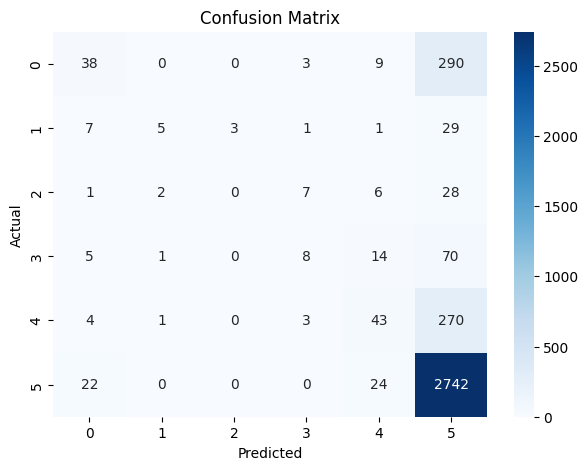

In [111]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#### **Observation:**

TF-IDF slightly improves overall accuracy but minority-class prediction remains difficult.

### **Multinomial Naive Bayes**

### CountVectorizer + Naive Bayes

In [112]:

clf_mn_nb = MultinomialNB()
clf_mn_nb.fit(X_train_count, y_train)
y_pred = clf_mn_nb.predict(X_test_count)

### Model Evaluation

In [113]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.736


In [114]:
# Weighted F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.723


In [115]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.19      0.23       340
           1       0.32      0.28      0.30        46
           2       0.19      0.09      0.12        44
           3       0.29      0.20      0.24        98
           4       0.30      0.35      0.32       321
           5       0.84      0.88      0.86      2788

    accuracy                           0.74      3637
   macro avg       0.37      0.33      0.35      3637
weighted avg       0.71      0.74      0.72      3637



#### **Observation:**

Naive Bayes provides competitive performance while being computationally efficient.

### **TF-IDF + Naive Bayes**

In [116]:
clf_mn_nb = MultinomialNB()
clf_mn_nb.fit(X_train_tfidf, y_train)
y_pred = clf_mn_nb.predict(X_test_tfidf)

### **Model Evaluation**

In [117]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.766


In [118]:
# Weighted F1 Score
f1 = f1_score(y_test, y_pred,average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.666


In [119]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.14      0.00      0.01       340
           1       0.00      0.00      0.00        46
           2       0.00      0.00      0.00        44
           3       0.00      0.00      0.00        98
           4       0.00      0.00      0.00       321
           5       0.77      1.00      0.87      2788

    accuracy                           0.77      3637
   macro avg       0.15      0.17      0.15      3637
weighted avg       0.60      0.77      0.67      3637



#### **Observation:**

Performance declines due to severe class imbalance and the dominance of positive reviews.

### Model Comparison

summary table:

| Model               | Vectorizer | Accuracy | Weighted F1 |
| ------------------- | ---------- | -------- | ----------- |
| Logistic Regression | Count      | 0.763    | 0.727       |
| Logistic Regression | TF-IDF     | 0.780    | 0.717       |
| Naive Bayes         | Count      | 0.736    | 0.723       |
| Naive Bayes         | TF-IDF     | 0.766    | 0.666       |

#### Observation:

Despite achieving reasonable accuracy, all models exhibit poor performance on minority rating classes.

## **13.Three-Class Sentiment Classification**

Predicting six rating classes proved challenging due to severe class imbalance. Therefore, ratings were grouped into broader sentiment categories.

| Stars | Sentiment |
| ----- | --------- |
| 0–2   | Negative  |
| 3     | Neutral   |
| 4–5   | Positive  |


In [120]:
# Create 3-class sentiment label from star ratings
def stars_to_sentiment(stars):
    """Convert 1-5 star rating to sentiment class"""
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['stars'].apply(stars_to_sentiment)

In [121]:
# Sentiment Distribution
df['sentiment'].value_counts()


,count
sentiment,
positive,15484
negative,2208
neutral,490


#### **Observation:**

The positive class still dominates the dataset.

## **14. Handling Class Imbalance with SMOTE**

Class imbalance caused models to favor positive reviews while largely ignoring minority classes. SMOTE was applied to generate synthetic minority samples within the training set.

In [122]:
# Debugged by AI
# Apply SMOTE
from imblearn.over_sampling import SMOTE

# Initialize SMOTE with default parameters
oversample = SMOTE(random_state=42)

# Define features (X) and target (y) for 3-class sentiment classification
X_sentiment = df['review']
y_sentiment = df['sentiment']

# Split data into training and testing sets
X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
    X_sentiment,
    y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment # Stratify to maintain class distribution
)

# Initialize and fit CountVectorizer on the training data for 3-class sentiment
# Reusing 'preprocess' function and general parameters.
sentiment_count_vectorizer = CountVectorizer(
    tokenizer=preprocess, # 'preprocess' function is defined globally
    min_df=2,
    max_features=2000
)
X_train_sentiment_vectorized = sentiment_count_vectorizer.fit_transform(X_train_sentiment)
X_test_sentiment_vectorized = sentiment_count_vectorizer.transform(X_test_sentiment)


# Apply SMOTE to the training data ONLY
X_train_resampled, y_train_resampled = oversample.fit_resample(X_train_sentiment_vectorized, y_train_sentiment)

print("Original training sentiment distribution (3 classes):")
print(y_train_sentiment.value_counts())
print("\nResampled training sentiment distribution (3 classes):")
print(pd.Series(y_train_resampled).value_counts())

Original training sentiment distribution (3 classes):
sentiment
positive    12387
negative     1766
neutral       392
Name: count, dtype: int64

Resampled training sentiment distribution (3 classes):
sentiment
positive    12387
neutral     12387
negative    12387
Name: count, dtype: int64


#### **Observation:**

SMOTE successfully balanced all sentiment classes.(a countplot was generated but omitted because it conveyed the same information as the balanced class counts.)

## **15. Sentiment Classification After SMOTE**

### Logistic Regression

In [123]:
# Logistic Regression after SMOTE:
clf_sentiment = LogisticRegression(max_iter=1000)
clf_sentiment.fit(X_train_resampled, y_train_resampled)
y_pred_sentiment = clf_sentiment.predict(X_test_sentiment_vectorized)

### Model Evaluation

In [124]:
# Accuracy
acc = accuracy_score(y_test_sentiment, y_pred_sentiment)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.746


In [125]:
# Weighted F1 Score
f1 = f1_score(y_test_sentiment, y_pred_sentiment, average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.773


In [126]:
# Classification Report
print(classification_report(y_test_sentiment, y_pred_sentiment))

              precision    recall  f1-score   support

    negative       0.27      0.36      0.31       442
     neutral       0.12      0.34      0.18        98
    positive       0.91      0.81      0.86      3097

    accuracy                           0.75      3637
   macro avg       0.43      0.50      0.45      3637
weighted avg       0.81      0.75      0.77      3637



#### **Observation:**

Recall for minority classes improves noticeably after balancing.

### Multinomial Naive Bayes

In [127]:
# Multinomial Naive Bayes after SMOTE
clf_mn_nb_sentiment = MultinomialNB()
clf_mn_nb_sentiment.fit(X_train_resampled, y_train_resampled)
y_pred_sentiment = clf_mn_nb_sentiment.predict(X_test_sentiment_vectorized)

### Model Evaluation

In [128]:
# Accuracy
acc = accuracy_score(y_test_sentiment, y_pred_sentiment)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.729


In [129]:
# Weighted F1 Score
f1 = f1_score(y_test_sentiment, y_pred_sentiment,average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')


Weighted F1 Score: 0.762


In [130]:
# Classification Report
print(classification_report(y_test_sentiment, y_pred_sentiment))

              precision    recall  f1-score   support

    negative       0.26      0.40      0.32       442
     neutral       0.11      0.31      0.17        98
    positive       0.91      0.79      0.84      3097

    accuracy                           0.73      3637
   macro avg       0.43      0.50      0.44      3637
weighted avg       0.81      0.73      0.76      3637



#### **Observation:**

Similar improvement is observed, although overall performance remains slightly below Logistic Regression.

### Linear SVC

In [131]:
from sklearn.svm import LinearSVC


clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(X_train_resampled, y_train_resampled)
y_pred = clf.predict(X_test_sentiment_vectorized)

### Model Evaluation

In [132]:
# Accuracy
acc = accuracy_score(y_test_sentiment, y_pred)

print(f'Accuracy: {acc:.3f}')

Accuracy: 0.754


In [133]:
# Weighted F1 Score
f1 = f1_score(y_test_sentiment, y_pred, average='weighted')

print(f'Weighted F1 Score: {f1:.3f}')

Weighted F1 Score: 0.777


In [134]:
# Classification Report
print(classification_report(y_test_sentiment, y_pred))

              precision    recall  f1-score   support

    negative       0.27      0.33      0.30       442
     neutral       0.11      0.28      0.15        98
    positive       0.90      0.83      0.86      3097

    accuracy                           0.75      3637
   macro avg       0.43      0.48      0.44      3637
weighted avg       0.80      0.75      0.78      3637



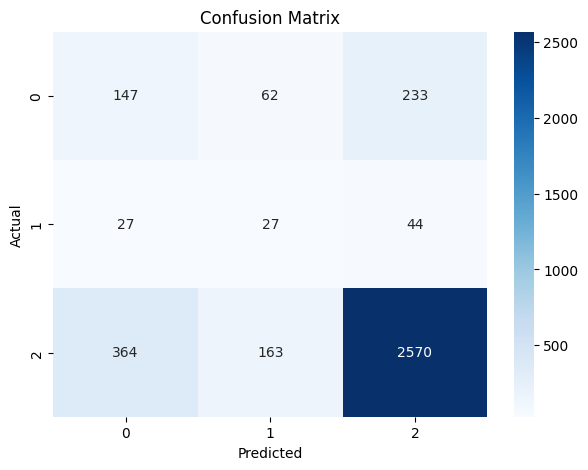

In [135]:
# Confusion Matrix
cm = confusion_matrix(y_test_sentiment, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#### **Observation:**

Linear SVC achieves the strongest overall performance after SMOTE, providing the best balance between majority and minority class prediction.

## **16. Final Model Comparison**

| Model                       | Accuracy | Weighted F1 |
| --------------------------- | -------- | ----------- |
| Logistic Regression + SMOTE | 0.745    | 0.772       |
| Naive Bayes + SMOTE         | 0.729    | 0.762       |
| Linear SVC + SMOTE          | 0.754    | 0.777       |



## **17. Key Findings**



1.   Review text contains meaningful sentiment information.
2.   VADER sentiment scores correlate with user star ratings.
3.   Class imbalance significantly impacts classification performance.
4.   TF-IDF slightly improves Logistic Regression accuracy.
5.   SMOTE improves minority-class recall and F1 scores.
6.   Linear SVC achieved the best overall performance.
7.   Predicting exact ratings remains considerably more difficult than predicting broader sentiment categories.







### **Overall Insight:**
While SMOTE helped balance the training data, predicting the minority 'negative' and 'neutral' sentiment classes remains challenging for all models, as indicated by their lower precision, recall, and F1 scores compared to the 'positive' class. Linear SVC shows the most promising overall performance among the three on this balanced (via SMOTE) 3-class sentiment task.


## **18.Semantic Similarity Experiment**

In [136]:
# Similarity Libraries

from sklearn.metrics.pairwise import cosine_similarity

In [137]:
# TF-IDF Matrix
dtm = tfidf_vectorizer.fit_transform(df['review'])

In [138]:
# Recipe Similarity Function
def find_similar_recipes(query, topk=15):

    query_vector = tfidf_vectorizer.transform([query])

    sim = cosine_similarity(dtm, query_vector)

    result = sorted(
        zip(df['recipe_name'], sim.ravel()),
        key=lambda x: x[1],
        reverse=True
    )

    top_results = result[:topk]

    dfc = pd.DataFrame(
        top_results,
        columns=['recipe', 'similarity']
    )

    res = dfc.groupby('recipe')['similarity'].sum()

    return res.sort_values(ascending=False)

In [139]:
# Example Query
query = 'creamy chicken sauce chili hot'

find_similar_recipes(query)

,similarity
recipe,
Creamy White Chili,2.761277
Favorite Dutch Apple Pie,0.468436
Creamy Grape Salad,0.452339
Black Bean ‘n’ Pumpkin Chili,0.421840
Taco Lasagna,0.404244
White Bean Chicken Chili,0.404105
Forgotten Jambalaya,0.400983
Creamy Macaroni and Cheese,0.390445
Comforting Chicken Noodle Soup,0.380802
